In [1]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

In [2]:
import pandas as pd
from rdkit.Chem import PandasTools

In [3]:
AA="C:/Users/ganes/OneDrive/Desktop/AI/Drug//DNA/DNA_Smiles_Final.xlsx"
df=pd.read_excel(AA)
df.head(5)
df=pd.read_excel(AA)
df.head(5)
df.shape

(762, 1)

In [4]:
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='Smiles', )
df.head(1)

,Smiles,ROMol
0,CCNCC1CCN(c2c(F)c(NC)c3c(=O)c(C(=O)O)cn(C4CC4)...,<rdkit.Chem.rdchem.Mol object at 0x000001AFE07...


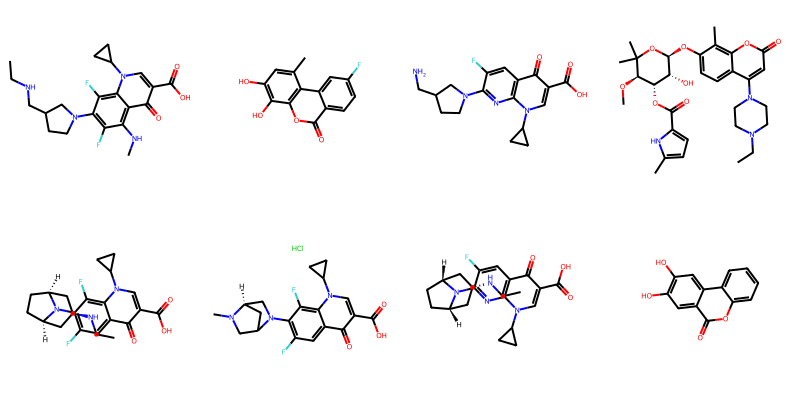

In [5]:
PandasTools.FrameToGridImage(df.head(8), molsPerRow=4)

In [6]:
radius = 3
nBits = 1024

DNA_SP = [AllChem.GetMorganFingerprintAsBitVect(x, radius=radius, nBits=nBits) for x in df['ROMol']]


[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerator
[11:56:43] DEPRECATION WARNING: please use MorganGenerat

In [7]:
len(DNA_SP[0])

1024

In [8]:
DNA_name = [f'Bit_{i}' for i in range(nBits)]
DNA_bits = [list(l) for l in DNA_SP]
df_DNA = pd.DataFrame(DNA_bits, index = df.Smiles, columns=DNA_name)
df_DNA.head(1)

,Bit_0,Bit_1,Bit_2,Bit_3,Bit_4,Bit_5,Bit_6,Bit_7,Bit_8,Bit_9,...,Bit_1014,Bit_1015,Bit_1016,Bit_1017,Bit_1018,Bit_1019,Bit_1020,Bit_1021,Bit_1022,Bit_1023
Smiles,,,,,,,,,,,,,,,,,,,,,
CCNCC1CCN(c2c(F)c(NC)c3c(=O)c(C(=O)O)cn(C4CC4)c3c2F)C1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [9]:
file_name = 'DNA_String.xlsx'
df_DNA.to_excel(file_name)